<a href="https://colab.research.google.com/github/datadigger01/AppStatMat/blob/main/PCA__serieal_ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 첨부된 파일의 데이터를 이용하여 PCA 즉 주성분 분석을 진행하고 결과를 시각화하려 한다.  주성분 분석에 사용되는 변수는 calories 부터 rating  컬럼의 데이터를 이용하여 진행하고,
# 2차원 평면에 제1주성분과 제2주성분을 기준으로 주성분 score를 plotting을 하되,
# plotting된 point에 name 컬럼에 이름을 같이 표시하고 싶어.  해당 내용을 진행하기 위한 절차와 python code를 제공해줘.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
# # 1. 데이터 로드
# df = pd.read_csv('cereal.csv')

# GitHub에서 CSV 파일 직접 로드
url = 'https://raw.githubusercontent.com/datadigger01/AppStatMat/main/Data/cereal.csv'
df = pd.read_csv(url)

# 데이터프레임의 처음 5행을 표시하여 확인
print("데이터프레임 로드 성공:")
print(df.info())
display(df.head())



데이터프레임 로드 성공:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      77 non-null     object 
 1   mfr       77 non-null     object 
 2   type      77 non-null     object 
 3   calories  77 non-null     int64  
 4   protein   77 non-null     int64  
 5   fat       77 non-null     int64  
 6   sodium    77 non-null     int64  
 7   fiber     77 non-null     float64
 8   carbo     77 non-null     float64
 9   sugars    77 non-null     int64  
 10  potass    77 non-null     int64  
 11  vitamins  77 non-null     int64  
 12  shelf     77 non-null     int64  
 13  weight    77 non-null     float64
 14  cups      77 non-null     float64
 15  rating    77 non-null     float64
dtypes: float64(5), int64(8), object(3)
memory usage: 9.8+ KB
None


,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843


- mlr: 시리얼 제조업체
- type: 저온용 또는 고온용
- calories : 1회분에 대한 칼로리
- protein : 단백질(g)
- fat : 지방(g)
- sodium : 나트륨(mg)
- fiber : 식이섬유(g)
- carbo : 복합 탄수화물(g)
- sugars : 설탕(g)
- potass : 칼륨(g)
- vitamins : 비타민과 미네랄:FDA의 권장비율로서 0, 25 또는 100을 나타냄
- shell :디스플레이 선반
- weight : 1회분의 무게(Ounces)
- rating : 소비자 보고서에 의한 시리얼 평점

결측치 확인:
calories    0
protein     0
fat         0
sodium      0
fiber       0
carbo       0
sugars      0
potass      0
vitamins    0
shelf       0
weight      0
cups        0
rating      0
dtype: int64

제1주성분 설명 분산: 0.2777
제2주성분 설명 분산: 0.2414
누적 설명 분산: 0.5191

주성분 적재량:
               PC1       PC2
calories -0.333258  0.354014
protein   0.303510  0.184091
fat      -0.061171  0.333425
sodium   -0.214987  0.128996
fiber     0.427689  0.236617
carbo    -0.194541 -0.155849
sugars   -0.268234  0.318593
potass    0.359694  0.349417
vitamins -0.150384  0.174544
shelf     0.113605  0.279502
weight   -0.094005  0.441786
cups     -0.271618 -0.250846
rating    0.454567 -0.205951



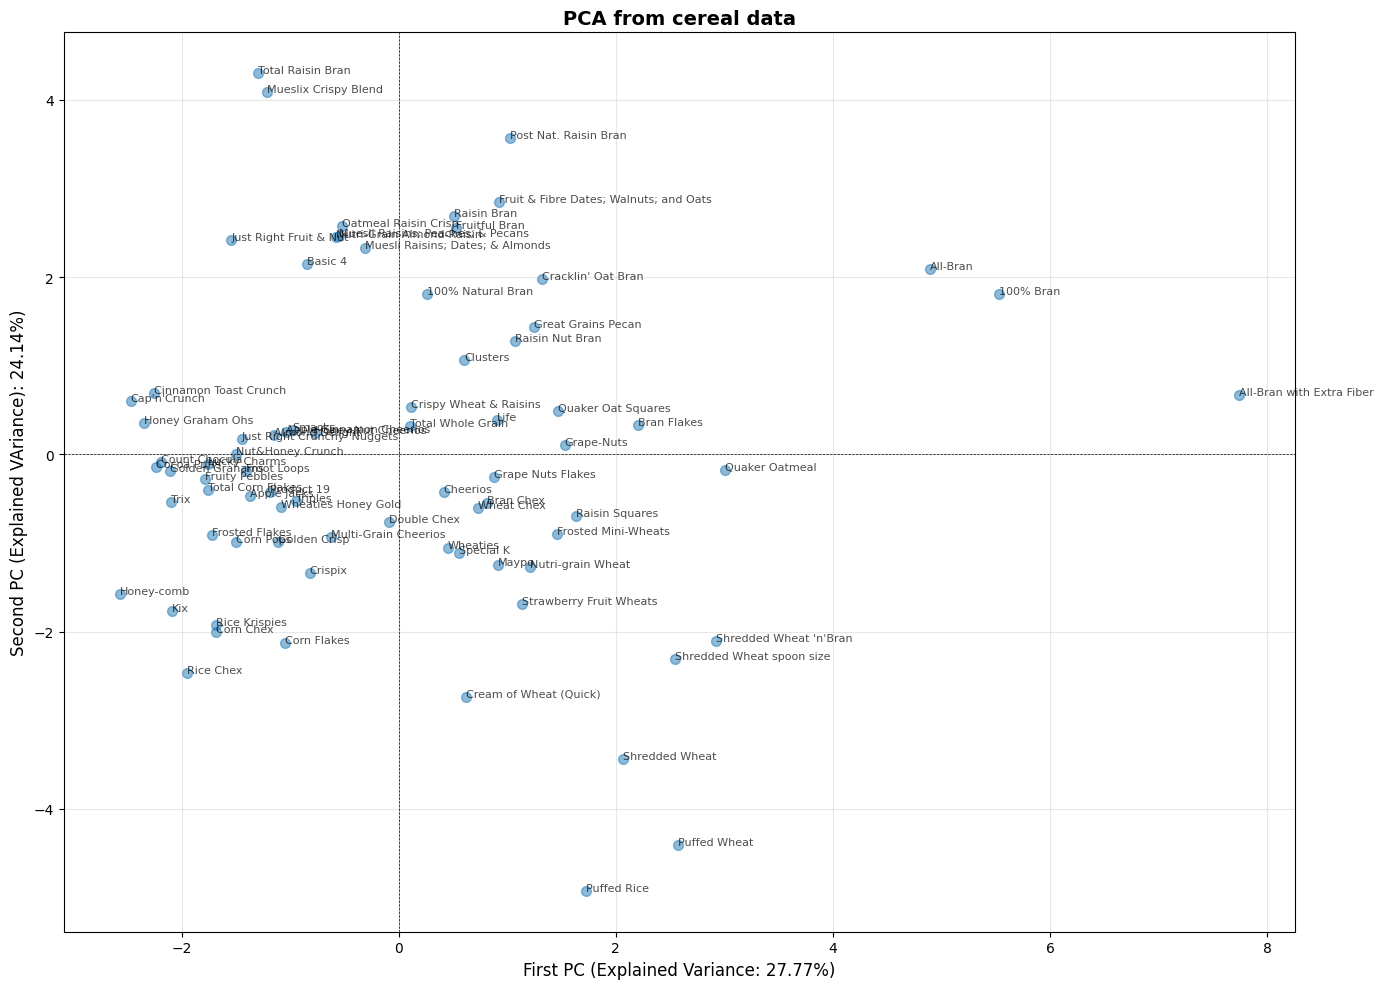


제1주성분에 큰 영향을 미치는 변수 (상위 5개):
rating      0.454567
fiber       0.427689
potass      0.359694
calories    0.333258
protein     0.303510
Name: PC1, dtype: float64

제2주성분에 큰 영향을 미치는 변수 (상위 5개):
weight      0.441786
calories    0.354014
potass      0.349417
fat         0.333425
sugars      0.318593
Name: PC2, dtype: float64


In [ ]:
# 2. 분석할 변수 선택 (calories부터 rating까지)
feature_columns = ['calories', 'protein', 'fat', 'sodium', 'fiber',
                   'carbo', 'sugars', 'potass', 'vitamins', 'shelf',
                   'weight', 'cups', 'rating']

# 특성 데이터와 시리얼 이름 분리
X = df[feature_columns]
cereal_names = df['name']

# 결측치 확인
print("결측치 확인:")
print(X.isnull().sum())
print()

# 결측치가 있다면 처리 (평균값으로 대체 또는 해당 행 제거)
X = X.fillna(X.mean())

# 3. 데이터 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. PCA 수행
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# PCA 결과를 DataFrame으로 변환
pca_df = pd.DataFrame(
    data=principal_components,
    columns=['PC1', 'PC2']
)
pca_df['name'] = cereal_names.values

# 5. 설명된 분산 비율 출력
print(f"제1주성분 설명 분산: {pca.explained_variance_ratio_[0]:.4f}")
print(f"제2주성분 설명 분산: {pca.explained_variance_ratio_[1]:.4f}")
print(f"누적 설명 분산: {pca.explained_variance_ratio_[:2].sum():.4f}")
print()

# 6. 주성분 적재량(Loading) 출력
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_columns
)
print("주성분 적재량:")
print(loadings)
print()

# 7. 시각화
plt.figure(figsize=(14, 10))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5, s=50)

# 각 포인트에 시리얼 이름 표시
for i, name in enumerate(pca_df['name']):
    plt.annotate(name,
                (pca_df['PC1'][i], pca_df['PC2'][i]),
                fontsize=8,
                alpha=0.7,
                ha='left')

plt.xlabel(f'First PC (Explained Variance: {pca.explained_variance_ratio_[0]:.2%})',
          fontsize=12)
plt.ylabel(f'Second PC (Explained VAriance): {pca.explained_variance_ratio_[1]:.2%})',
          fontsize=12)
plt.title('PCA from cereal data', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# 8. 추가 분석: 주성분에 가장 큰 영향을 미치는 변수 확인
print("\n제1주성분에 큰 영향을 미치는 변수 (상위 5개):")
pc1_importance = loadings['PC1'].abs().sort_values(ascending=False)
print(pc1_importance.head())

print("\n제2주성분에 큰 영향을 미치는 변수 (상위 5개):")
pc2_importance = loadings['PC2'].abs().sort_values(ascending=False)
print(pc2_importance.head())